In [1]:
"""
Loop de entrenamiento genérico para modelos AMC con PyTorch puro.
Compatible con CNN, LSTM y cualquier arquitectura que definas.
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
import matplotlib.pyplot as plt
import polars as pl
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [12]:

# -----------------------------------------------------------------
# 1. Cargar dataset filtrado (generado en eda_radioml.py)
# -----------------------------------------------------------------
X = np.load("../rfml/radioml_X_digital.npy")           # (160000, 2, 128)
meta = pl.read_parquet("../rfml/radioml_metadata_digital.parquet")

mods = meta["mod"].to_numpy()
snrs = meta["snr"].to_numpy()

# Encodear etiquetas a enteros
le = LabelEncoder()
y = le.fit_transform(mods)

print(f"Clases: {le.classes_}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

print(X.shape)
print(meta.head(10))
print(meta["mod"].value_counts())

# Verificar que X y meta tienen el mismo largo
print(f"X: {len(X)}, meta: {len(meta)}")

# Ver las primeras etiquetas
le = LabelEncoder()
y = le.fit_transform(meta["mod"].to_numpy())
print(f"Clases: {le.classes_}")
print(f"Primeras 10 etiquetas: {y[:10]}")
print(f"Últimas 10 etiquetas: {y[-10:]}")
# Mezclar todo el dataset antes del split
np.random.seed(42)
idx = np.random.permutation(len(X))
X = X[idx]
y = y[idx]
snrs = snrs[idx]

print("Primeras 10 etiquetas después de mezclar:", y[:10])

Clases: ['8PSK' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64' 'QPSK']
X shape: (160000, 2, 128), y shape: (160000,)
(160000, 2, 128)
shape: (10, 2)
┌──────┬─────┐
│ mod  ┆ snr │
│ ---  ┆ --- │
│ str  ┆ i64 │
╞══════╪═════╡
│ QPSK ┆ 2   │
│ QPSK ┆ 2   │
│ QPSK ┆ 2   │
│ QPSK ┆ 2   │
│ QPSK ┆ 2   │
│ QPSK ┆ 2   │
│ QPSK ┆ 2   │
│ QPSK ┆ 2   │
│ QPSK ┆ 2   │
│ QPSK ┆ 2   │
└──────┴─────┘
shape: (8, 2)
┌───────┬───────┐
│ mod   ┆ count │
│ ---   ┆ ---   │
│ str   ┆ u32   │
╞═══════╪═══════╡
│ 8PSK  ┆ 20000 │
│ BPSK  ┆ 20000 │
│ QAM64 ┆ 20000 │
│ GFSK  ┆ 20000 │
│ QAM16 ┆ 20000 │
│ QPSK  ┆ 20000 │
│ PAM4  ┆ 20000 │
│ CPFSK ┆ 20000 │
└───────┴───────┘
X: 160000, meta: 160000
Clases: ['8PSK' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64' 'QPSK']
Primeras 10 etiquetas: [7 7 7 7 7 7 7 7 7 7]
Últimas 10 etiquetas: [1 1 1 1 1 1 1 1 1 1]
Primeras 10 etiquetas después de mezclar: [6 1 0 5 7 2 6 1 3 7]


In [13]:

# -----------------------------------------------------------------
# 2. Split train / val / test (60 / 20 / 20)
# -----------------------------------------------------------------
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X, y, snrs, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (96000, 2, 128), Val: (32000, 2, 128), Test: (32000, 2, 128)


In [14]:

# -----------------------------------------------------------------
# 3. DataLoaders
# -----------------------------------------------------------------
def make_loader(X, y, batch_size=256, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)


In [15]:

# -----------------------------------------------------------------
# 4. Definición de modelos
# -----------------------------------------------------------------

class CNNBaseline(nn.Module):
    """CNN de O'Shea et al. (2016) — baseline estándar."""
    def __init__(self, n_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 128, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class LSTMClassifier(nn.Module):
    """LSTM para clasificación de modulaciones."""
    def __init__(self, input_size=2, hidden_size=128, num_layers=2, n_classes=8):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.5
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)   # (batch, 2, 128) → (batch, 128, 2)
        out, _ = self.lstm(x)
        out = out[:, -1, :]       # último estado oculto
        return self.classifier(out)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)



In [16]:

# -----------------------------------------------------------------
# 5. Loop de entrenamiento genérico
# -----------------------------------------------------------------
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, device="cpu"):
    model = model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_weights = None

    for epoch in range(epochs):
        # --- Entrenamiento ---
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # --- Validación ---
        model.eval()
        val_losses, correct, total = [], 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_losses.append(loss.item())
                preds = logits.argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total += len(y_batch)

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        val_acc    = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"Época {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val Acc: {val_acc:.4f}")

    # Cargar mejores pesos
    model.load_state_dict(best_weights)
    return model, history


# -----------------------------------------------------------------
# 6. Evaluación por SNR
# -----------------------------------------------------------------
def evaluate_by_snr(model, X_test, y_test, snr_test, device="cpu"):
    model.eval()
    snr_levels = sorted(np.unique(snr_test))
    results = {}

    with torch.no_grad():
        for snr in snr_levels:
            mask = snr_test == snr
            X_snr = torch.tensor(X_test[mask], dtype=torch.float32).to(device)
            y_snr = torch.tensor(y_test[mask], dtype=torch.long).to(device)
            logits = model(X_snr)
            preds = logits.argmax(dim=1)
            acc = (preds == y_snr).float().mean().item()
            results[snr] = acc

    return results



In [17]:

# -----------------------------------------------------------------
# 7. Entrenamiento y comparación
# -----------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_CLASSES = len(le.classes_)
EPOCHS = 50

print(f"\nUsando dispositivo: {DEVICE}")

# CNN
print("\n=== Entrenando CNN ===")
cnn = CNNBaseline(n_classes=N_CLASSES)
print(f"Parámetros CNN: {cnn.count_parameters():,}")
cnn, cnn_history = train_model(cnn, train_loader, val_loader, epochs=EPOCHS, device=DEVICE)
torch.save(cnn.state_dict(), "cnn_custom.pt")

# LSTM
print("\n=== Entrenando LSTM ===")
lstm = LSTMClassifier(n_classes=N_CLASSES)
print(f"Parámetros LSTM: {lstm.count_parameters():,}")
lstm, lstm_history = train_model(lstm, train_loader, val_loader, epochs=EPOCHS, device=DEVICE)
torch.save(lstm.state_dict(), "lstm_custom.pt")



Usando dispositivo: cpu

=== Entrenando CNN ===
Parámetros CNN: 1,062,536
Época  10/50 | Train Loss: 2.0795 | Val Loss: 2.0794 | Val Acc: 0.1250
Época  20/50 | Train Loss: 2.0795 | Val Loss: 2.0795 | Val Acc: 0.1250
Época  30/50 | Train Loss: 2.0795 | Val Loss: 2.0794 | Val Acc: 0.1250
Época  40/50 | Train Loss: 2.0795 | Val Loss: 2.0795 | Val Acc: 0.1250
Época  50/50 | Train Loss: 2.0795 | Val Loss: 2.0795 | Val Acc: 0.1250

=== Entrenando LSTM ===
Parámetros LSTM: 208,456
Época  10/50 | Train Loss: 2.0795 | Val Loss: 2.0795 | Val Acc: 0.1250
Época  20/50 | Train Loss: 2.0795 | Val Loss: 2.0794 | Val Acc: 0.1250
Época  30/50 | Train Loss: 2.0795 | Val Loss: 2.0794 | Val Acc: 0.1250
Época  40/50 | Train Loss: 2.0795 | Val Loss: 2.0794 | Val Acc: 0.1250
Época  50/50 | Train Loss: 2.0795 | Val Loss: 2.0795 | Val Acc: 0.1250


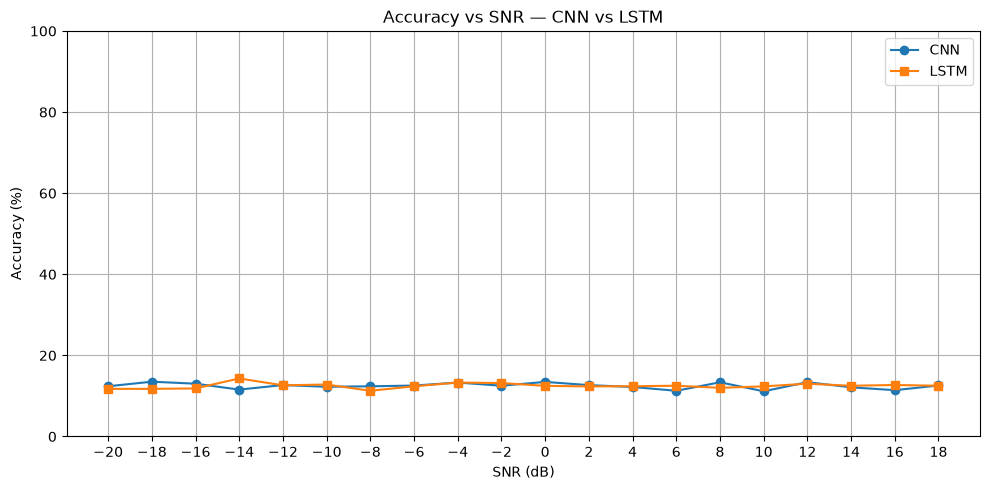

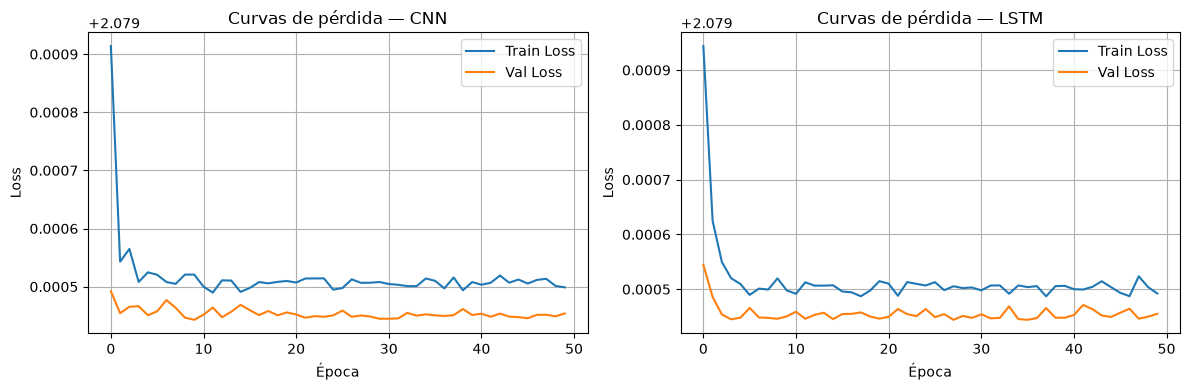


=== Resumen de complejidad ===
CNN  — Parámetros: 1,062,536
LSTM — Parámetros: 208,456


In [20]:

# -----------------------------------------------------------------
# 8. Accuracy por SNR
# -----------------------------------------------------------------
cnn_snr  = evaluate_by_snr(cnn,  X_test, y_test, snr_test, device=DEVICE)
lstm_snr = evaluate_by_snr(lstm, X_test, y_test, snr_test, device=DEVICE)

snr_levels = sorted(cnn_snr.keys())

plt.figure(figsize=(10, 5))
plt.plot(snr_levels, [cnn_snr[s] * 100  for s in snr_levels], marker="o", label="CNN")
plt.plot(snr_levels, [lstm_snr[s] * 100 for s in snr_levels], marker="s", label="LSTM")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — CNN vs LSTM")
plt.legend()
plt.grid(True)
plt.xticks(snr_levels)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("accuracy_vs_snr_comparacion.png", dpi=150)
plt.show()

# -----------------------------------------------------------------
# 9. Curvas de pérdida
# -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, history, name in zip(axes, [cnn_history, lstm_history], ["CNN", "LSTM"]):
    ax.plot(history["train_loss"], label="Train Loss")
    ax.plot(history["val_loss"],   label="Val Loss")
    ax.set_title(f"Curvas de pérdida — {name}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig("curvas_perdida.png", dpi=150)
plt.show()

print("\n=== Resumen de complejidad ===")
print(f"CNN  — Parámetros: {cnn.count_parameters():,}")
print(f"LSTM — Parámetros: {lstm.count_parameters():,}")

In [19]:
# Cuántos parámetros tiene cada modelo actualmente?
print(f"CNN: {cnn.count_parameters():,}")
print(f"LSTM: {lstm.count_parameters():,}")

CNN: 1,062,536
LSTM: 208,456


In [22]:
# Diagnóstico completo
import numpy as np
import polars as pl
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = np.load('../rfml/radioml_X_digital.npy')
meta = pl.read_parquet('../rfml/radioml_metadata_digital.parquet')
mods = meta['mod'].to_numpy()
snrs = meta['snr'].to_numpy()

le = LabelEncoder()
y = le.fit_transform(mods)

# Verificar ANTES del shuffle
print("=== ANTES del shuffle ===")
print("Primeras 20 etiquetas:", y[:20])
print("Clases:", [le.classes_[i] for i in y[:20]])

# Shuffle
np.random.seed(42)
idx = np.random.permutation(len(X))
X = X[idx]
y = y[idx]
snrs = snrs[idx]

# Verificar DESPUÉS del shuffle
print("\n=== DESPUÉS del shuffle ===")
print("Primeras 20 etiquetas:", y[:20])
print("Clases:", [le.classes_[i] for i in y[:20]])

# Split
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X, y, snrs, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Verificar distribución en train
print("\n=== Distribución en train ===")
for i, cls in enumerate(le.classes_):
    count = (y_train == i).sum()
    print(f"{cls}: {count}")

# Verificar que X e y están alineados
print("\n=== Verificación de alineación ===")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_train[0] media: {X_train[0].mean():.4f}")
print(f"y_train[0]: {y_train[0]} ({le.classes_[y_train[0]]})")

=== ANTES del shuffle ===
Primeras 20 etiquetas: [7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7]
Clases: ['QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK']

=== DESPUÉS del shuffle ===
Primeras 20 etiquetas: [6 1 0 5 7 2 6 1 3 7 1 5 2 2 5 6 0 5 6 6]
Clases: ['QAM64', 'BPSK', '8PSK', 'QAM16', 'QPSK', 'CPFSK', 'QAM64', 'BPSK', 'GFSK', 'QPSK', 'BPSK', 'QAM16', 'CPFSK', 'CPFSK', 'QAM16', 'QAM64', '8PSK', 'QAM16', 'QAM64', 'QAM64']

=== Distribución en train ===
8PSK: 12000
BPSK: 12000
CPFSK: 12000
GFSK: 12000
PAM4: 12000
QAM16: 12000
QAM64: 12000
QPSK: 12000

=== Verificación de alineación ===
X_train shape: (96000, 2, 128)
y_train shape: (96000,)
X_train[0] media: -0.0003
y_train[0]: 5 (QAM16)


In [23]:
import torch
import torch.nn as nn

# Verificar que el modelo se inicializa desde cero (NO cargar pesos viejos)
cnn = CNNBaseline(n_classes=8)
print(f'Parámetros CNN: {cnn.count_parameters():,}')

# Test rápido: ¿el modelo da predicciones distintas para distintas entradas?
X_sample = torch.tensor(X_train[:10], dtype=torch.float32)
with torch.no_grad():
    logits = cnn(X_sample)
    preds = logits.argmax(dim=1)
    print('Predicciones iniciales (deben ser variadas):', preds.numpy())
    print('Logits (deben ser valores distintos):', logits[0].numpy())

Parámetros CNN: 1,062,536
Predicciones iniciales (deben ser variadas): [7 7 7 3 7 7 7 3 7 7]
Logits (deben ser valores distintos): [-0.03007706  0.01142371 -0.0398085   0.07387315 -0.03882058  0.07609103
 -0.04508318  0.09290549]
